In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model

In [2]:
train = pd.read_csv("train.csv", parse_dates=["Month"], index_col="Month")
test = pd.read_csv("test.csv", parse_dates=["Month"], index_col="Month")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (2256, 1)
Test shape: (564, 1)


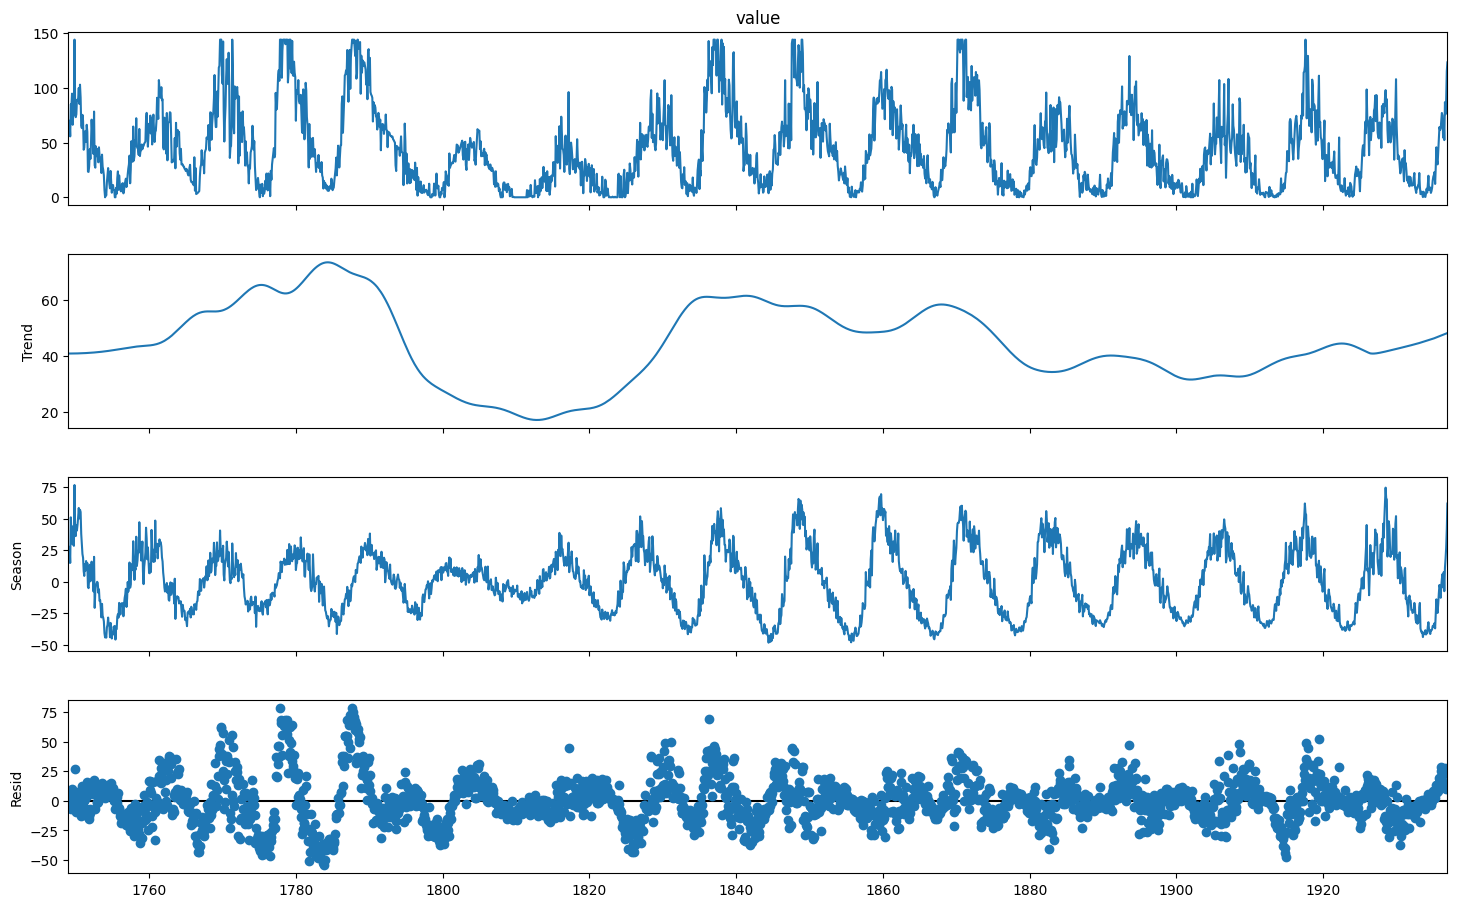

In [ ]:
stl = STL(train["value"], period=132)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(16, 10)

plt.show()

In [6]:
model = ExponentialSmoothing(
    train["value"],
    trend="add",
    seasonal="add",
    seasonal_periods=132
)

fit = model.fit()

e:\Python\ts_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
e:\Python\ts_venv\lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [7]:
pred = fit.forecast(len(test))

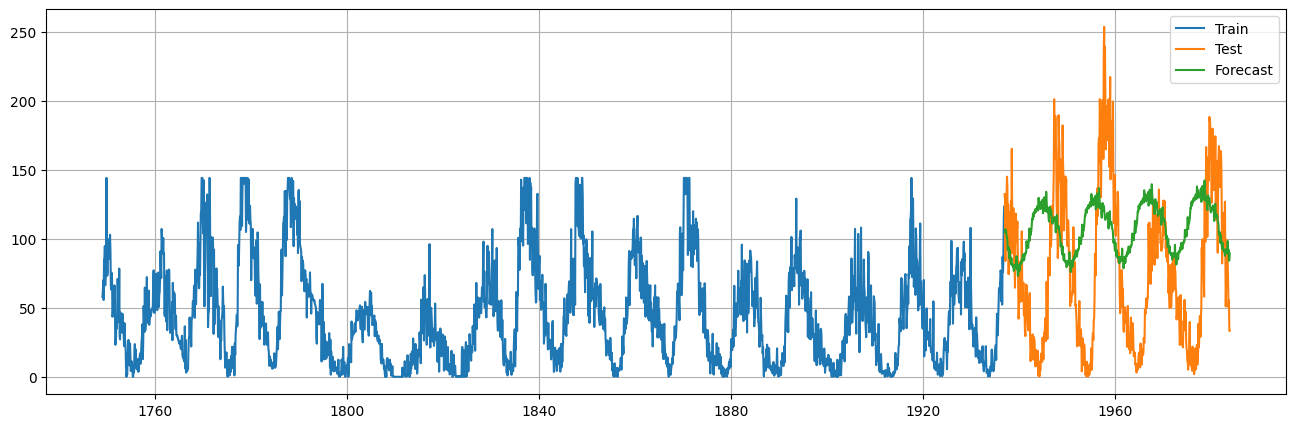

In [8]:
plt.figure(figsize=(16, 5))

plt.plot(train.index, train["value"], label="Train")
plt.plot(test.index, test["value"], label="Test")
plt.plot(test.index, pred, label="Forecast")

plt.legend()
plt.grid()

plt.show()

In [10]:
residuals = test["value"] - pred
squared_residuals = residuals ** 2

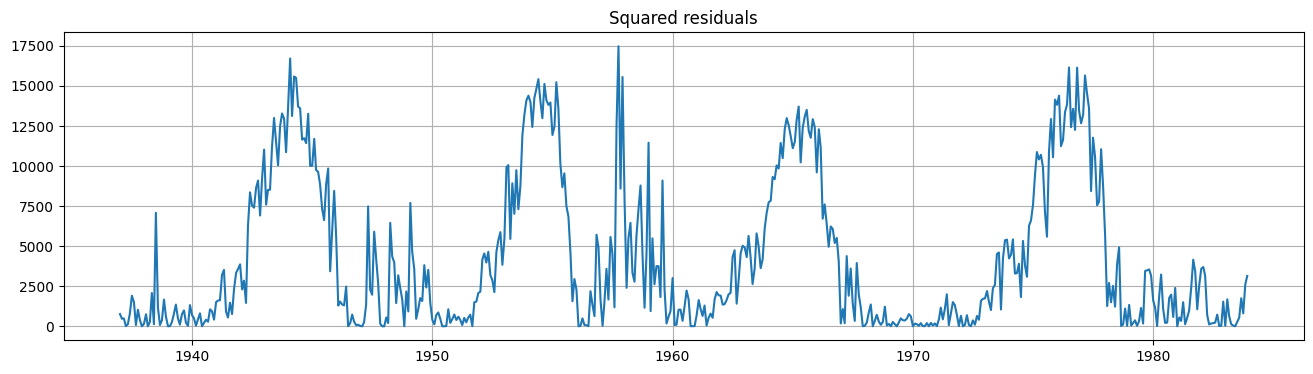

In [11]:
plt.figure(figsize=(16, 4))
plt.plot(squared_residuals)
plt.grid()
plt.title("Squared residuals")
plt.show()

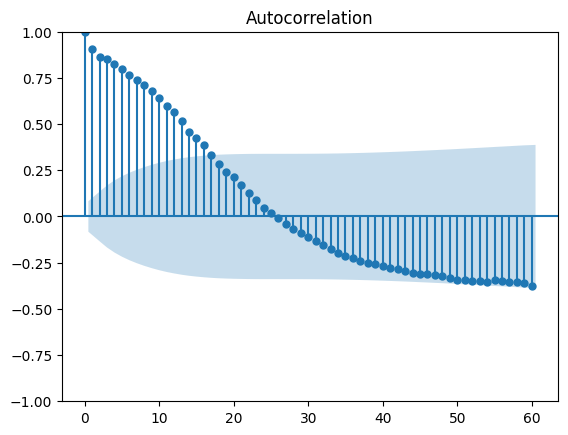

In [12]:
plot_acf(squared_residuals, lags=60)
plt.show()

In [ ]:
garch = arch_model(residuals, vol="GARCH", p=1, q=1)
garch_fit = garch.fit(disp="off")

In [ ]:
forecast = garch_fit.forecast(horizon=len(test), reindex=False)
volatility = forecast.variance.values[-1] ** 0.5

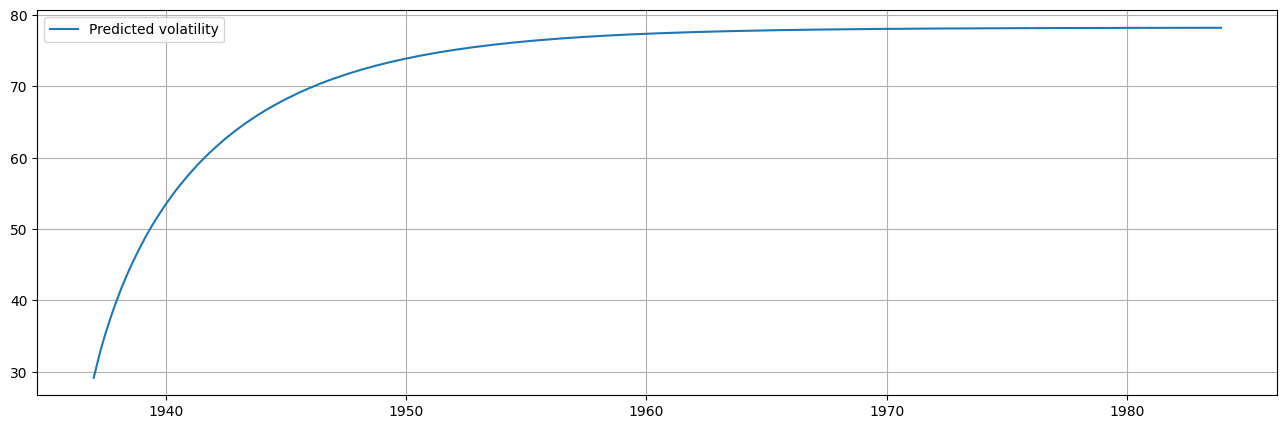

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(test.index, volatility, label="Predicted volatility")
plt.grid()
plt.legend()
plt.show()